In [15]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import Ridge, Lasso
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import matplotlib.pyplot as plt
import seaborn as sns

In [16]:
# Cargar datos
df = pd.read_csv(r'C:\Users\jenar\!clases\TC2004B-Jenaro\data\housing_messy.csv')

In [17]:
df['price_bin'] = pd.qcut(df['price'], q=4, labels=False)
X = df.drop(['price', 'price_bin'], axis=1)
y = df['price']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=df['price_bin']
)

In [18]:
# --- MODELO A: Ridge con alpha=0.1 ---
pipe_a = Pipeline([
    ('scaler', StandardScaler()),
    ('model', Ridge(alpha=0.1))
])
pipe_a.fit(X_train, y_train)
pred_a = pipe_a.predict(X_test)

# --- MODELO B: Ridge con alpha=10 ---
pipe_b = Pipeline([
    ('scaler', StandardScaler()),
    ('model', Ridge(alpha=10))
])
pipe_b.fit(X_train, y_train)
pred_b = pipe_b.predict(X_test)

# --- MODELO C: Lasso con alpha=5 ---
pipe_c = Pipeline([
    ('scaler', StandardScaler()),
    ('model', Lasso(alpha=5))
])
pipe_c.fit(X_train, y_train)
pred_c = pipe_c.predict(X_test)

# --- MODELO D: Ridge sin casas de ultra-lujo ---
mask_train = y_train < 1000  # Solo casas <$1M
mask_test = y_test < 1000

pipe_d = Pipeline([
    ('scaler', StandardScaler()),
    ('model', Ridge(alpha=1))
])
pipe_d.fit(X_train[mask_train], y_train[mask_train])
pred_d = pipe_d.predict(X_test[mask_test])

In [19]:
# Función para calcular métricas
def evaluate_model(y_true, y_pred, name):
    print(f"\n=== {name} ===")
    print(f"RMSE: {np.sqrt(mean_squared_error(y_true, y_pred)):.2f}")
    print(f"MAE: {mean_absolute_error(y_true, y_pred):.2f}")
    print(f"R2: {r2_score(y_true, y_pred):.3f}")
    
    # MAPE (cuidado con valores pequeños)
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
    print(f"MAPE: {mape:.2f}%")
    
    # Percentil 95 del error absoluto
    p95 = np.percentile(np.abs(y_true - y_pred), 95)
    print(f"95th percentile |error|: {p95:.2f}")

# Evaluar todos
evaluate_model(y_test, pred_a, "Modelo A: Ridge(alpha=0.1)")
evaluate_model(y_test, pred_b, "Modelo B: Ridge(alpha=10)")
evaluate_model(y_test, pred_c, "Modelo C: Lasso(alpha=5)")
evaluate_model(y_test[mask_test], pred_d, "Modelo D: Ridge sin casas de lujo")


=== Modelo A: Ridge(alpha=0.1) ===
RMSE: 335.22
MAE: 227.70
R2: 0.807
MAPE: 112.58%
95th percentile |error|: 490.04

=== Modelo B: Ridge(alpha=10) ===
RMSE: 339.62
MAE: 223.67
R2: 0.802
MAPE: 107.28%
95th percentile |error|: 454.63

=== Modelo C: Lasso(alpha=5) ===
RMSE: 336.36
MAE: 224.64
R2: 0.805
MAPE: 109.77%
95th percentile |error|: 472.07

=== Modelo D: Ridge sin casas de lujo ===
RMSE: 40.89
MAE: 32.73
R2: 0.804
MAPE: 18.22%
95th percentile |error|: 79.20


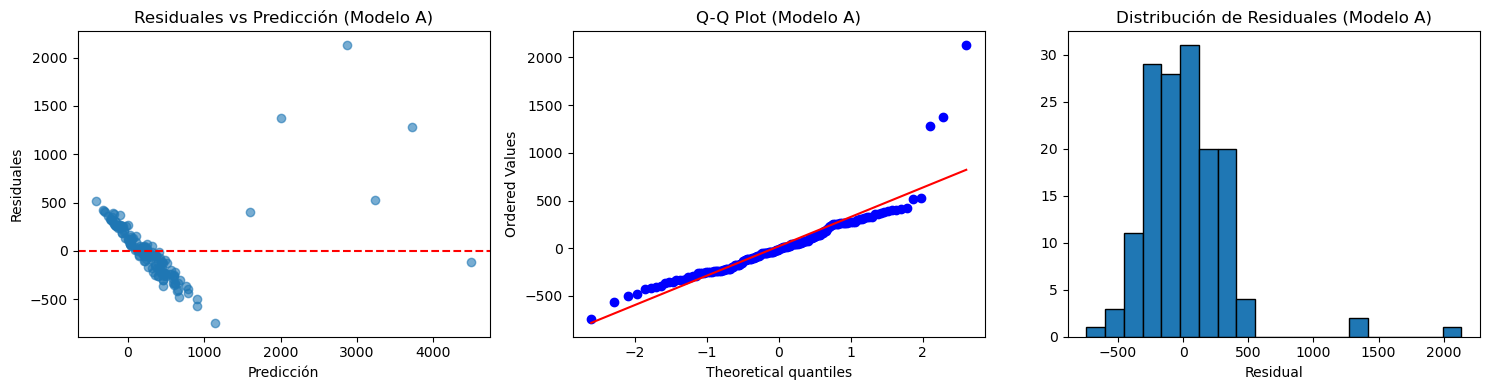

In [ ]:
# Diagnósticos para Modelo A
residuals_a = y_test - pred_a

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Residuales vs predichos
axes[0].scatter(pred_a, residuals_a, alpha=0.6)
axes[0].axhline(0, color='red', linestyle='--')
axes[0].set_xlabel('Predicción')
axes[0].set_ylabel('Residuales')
axes[0].set_title('Residuales vs Predicción (Modelo A)')

# Q-Q plot
from scipy import stats
stats.probplot(residuals_a, dist="norm", plot=axes[1])
axes[1].set_title('Q-Q Plot (Modelo A)')

# Histograma de errores
axes[2].hist(residuals_a, bins=20, edgecolor='black')
axes[2].set_xlabel('Residual')
axes[2].set_title('Distribución de Residuales (Modelo A)')

plt.tight_layout()
plt.show()

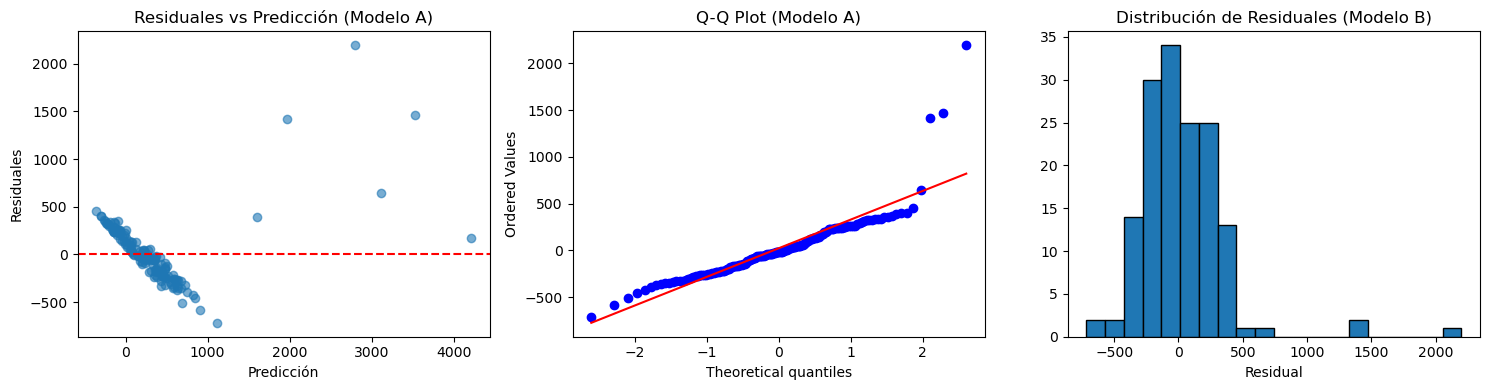

In [ ]:
# Diagnósticos para Modelo A
residuals_b = y_test - pred_b

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Residuales vs predichos
axes[0].scatter(pred_b, residuals_b, alpha=0.6)
axes[0].axhline(0, color='red', linestyle='--')
axes[0].set_xlabel('Predicción')
axes[0].set_ylabel('Residuales')
axes[0].set_title('Residuales vs Predicción (Modelo A)')

# Q-Q plot
from scipy import stats
stats.probplot(residuals_b, dist="norm", plot=axes[1])
axes[1].set_title('Q-Q Plot (Modelo A)')

# Histograma de errores
axes[2].hist(residuals_b, bins=20, edgecolor='black')
axes[2].set_xlabel('Residual')
axes[2].set_title('Distribución de Residuales (Modelo B)')

plt.tight_layout()
plt.show()

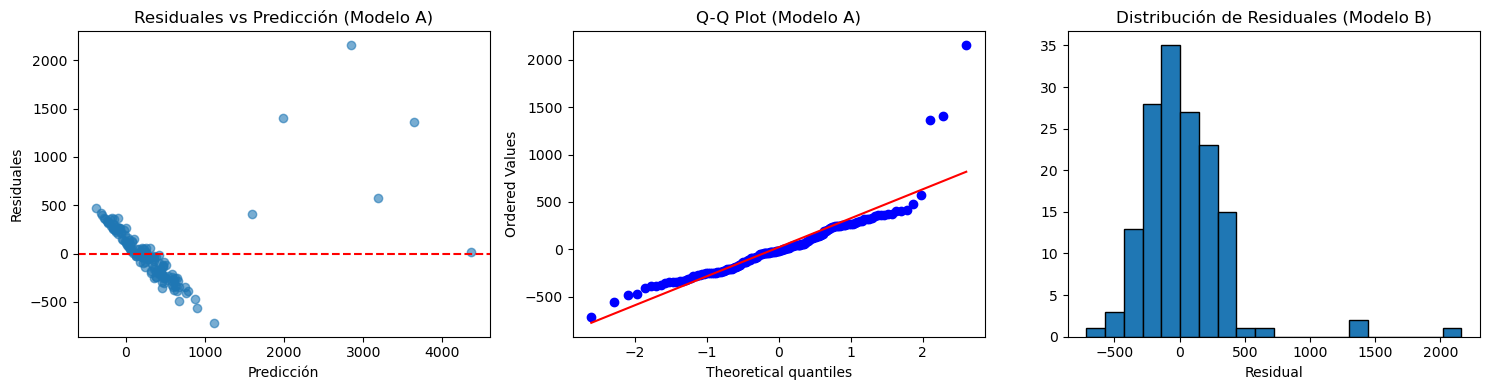

In [ ]:
# Diagnósticos para Modelo A
residuals_c = y_test - pred_c

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Residuales vs predichos
axes[0].scatter(pred_c, residuals_c, alpha=0.6)
axes[0].axhline(0, color='red', linestyle='--')
axes[0].set_xlabel('Predicción')
axes[0].set_ylabel('Residuales')
axes[0].set_title('Residuales vs Predicción (Modelo A)')

# Q-Q plot
from scipy import stats
stats.probplot(residuals_c, dist="norm", plot=axes[1])
axes[1].set_title('Q-Q Plot (Modelo A)')

# Histograma de errores
axes[2].hist(residuals_c, bins=20, edgecolor='black')
axes[2].set_xlabel('Residual')
axes[2].set_title('Distribución de Residuales (Modelo B)')

plt.tight_layout()
plt.show()

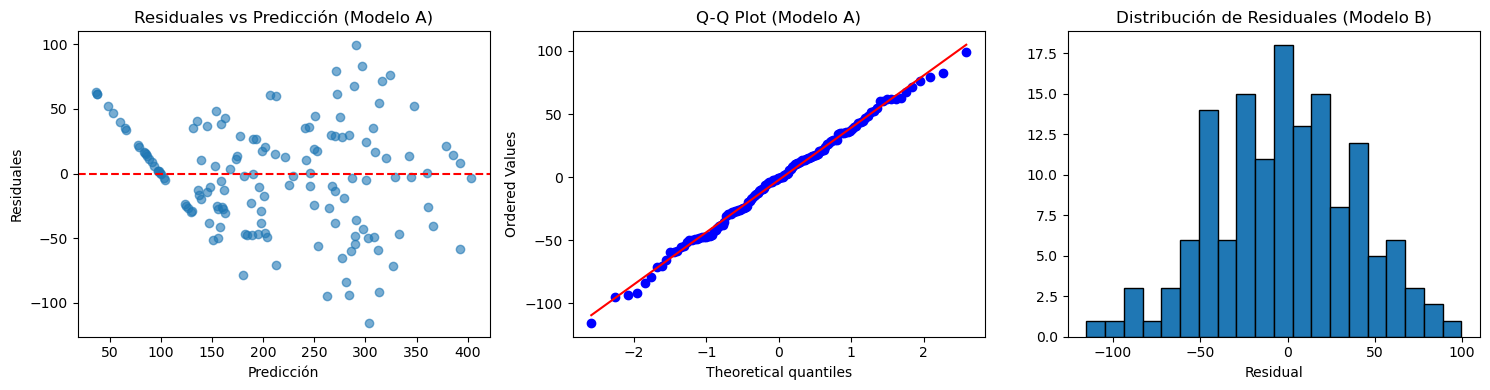

In [ ]:
# Diagnósticos para Modelo A
residuals_d = y_test[mask_test] - pred_d

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Residuales vs predichos
axes[0].scatter(pred_d, residuals_d, alpha=0.6)
axes[0].axhline(0, color='red', linestyle='--')
axes[0].set_xlabel('Predicción')
axes[0].set_ylabel('Residuales')
axes[0].set_title('Residuales vs Predicción (Modelo A)')

# Q-Q plot
from scipy import stats
stats.probplot(residuals_d, dist="norm", plot=axes[1])
axes[1].set_title('Q-Q Plot (Modelo A)')

# Histograma de errores
axes[2].hist(residuals_d, bins=20, edgecolor='black')
axes[2].set_xlabel('Residual')
axes[2].set_title('Distribución de Residuales (Modelo B)')

plt.tight_layout()
plt.show()

### Parte 1: Interpretación de Resultados 
Basándote en las métricas generadas:

##### 1.1 El Modelo A tiene el RMSE más bajo pero el percentil 95 más alto. El Modelo B tiene RMSE más alto pero percentil 95 más bajo. ¿Qué está pasando? ¿Qué dice esto sobre cómo cada modelo maneja los errores? 

R.- Los errores del modelo A tiene un primedio bajo, por lo que no contribuyen al aumento del RMSE. Sin embargo, su percentil 95 es alto, lo que indica que se equivoca gravemente de vez en cuando. Por el contrario, el modelo B tiene el RMSE mas alto lo que sugiere que el promedio de sus errores es mas alto pero no comete errores igual de graves como el A ya que su percentil 65 es mas bajo. 

#### 1.2 Los diagnósticos del Modelo A muestran heterocedasticidad clara (residuales crecen con la predicción). ¿Esto invalida el modelo? ¿Qué implicaciones tiene para cada uno de los tres usos (A, B, C)? 

R.-No necesariamente se invalida el modelo poruqe depende del uso. Para el caso A, no lo usaria debido a que las propiedades caras tendran mas errores. Obviamente depende de que busque el cliente pero si quiere una propiedad con caracteristicas de propiedad cara y su prediccion de valuacion puede tener un errore muy grave y asi perderiamos la conifanza del cliente. Podria usarse en este caso para mostrar rangos de precios y especificar que entre mas cara sea una propiedad su precio puede variar bastante. Para el uso B de plano no lo usaria por que precisamente es una comparacion directa del precio predicho con el real. Imaginemos que pensamos que una propiedad va a ser barata por un errore de modelo y en realidad no. Es un falso positivo en terminos de realizar la compra de la propiedad. Basicamente nos podria ilusionar mucho este modelo o nos podria llevar a decisiones de inversion que pueden lastimar mucho a la compañia. Para el uso C si lo usaria. La hesterostecidad no tiene mucho impacto cuanto queremos reportar estadisticas extras. Puede servir para explicar tendencias del mercado sin necesidad de querer una prediccion. El modelo sigue siendo bueno para analisis complementario.

#### 1.3 El Modelo D tiene mejor MAPE que todos los demás, pero está entrenado sin las casas de lujo. ¿Es válido reportarlo? ¿En qué situación lo usarías vs cuándo no? 

R.- Si es valido reportarlo pero su uso cambia. Es cierto que es el modelo con el menor error (por haber quitado las casas de lujo), pero tenemos que cambiar su enfoque. Debido a que quitamos las casas de lujo, el modelo no va a poder una prediccion confiable ya que no puede generalizar informacion acerca de estas por que en teoria no conoce ninguna. Por esto no es comparable directamente (como con las metricas) con el resto de modelos. Es un modelo con uso solo para casas no de lujo.

#### Parte 2: Decisión Justificada (40%)

#### 2.1 Elección de métrica

La empresa quiere "un solo número" para comparar modelos.

Tienes que elegir UNA métrica principal.

Escribe un memo a la directora técnica donde:

Recomiendas qué métrica usar (RMSE, MAE, MAPE, R2, otra)
Explicas por qué esa métrica es apropiada para este problema específico
Reconoces qué limitaciones tiene tu elección
Mencionas si recomiendas reportar métricas secundarias

R.-

#### 2.2 Selección de modelo

Ahora tienes que elegir UN modelo de los cuatro para poner en producción.

Escribe tu recomendación justificando:

Qué modelo elegiste y por qué
Qué modelo(s) descartaste y por qué (esto es tan importante como lo anterior)
Para cuál de los tres usos (A, B, C) tu elección es más/menos apropiada
Qué riesgos tiene tu elección (ningún modelo es perfecto)
Qué le dirías al equipo de producto sobre las limitaciones del modelo


### Parte 3: Pensamiento Crítico (30%)

#### 3.1 El caso de las casas de lujo 

Las 15 casas de ultra-lujo ($2M+) representan solo el 3% de los datos pero dominan las métricas.

Un colega te propone: "Eliminémoslas. Son outliers. El modelo será mucho mejor."

Responde:

¿Estás de acuerdo? ¿Por qué sí o por qué no?
Si las eliminas, ¿qué estás asumiendo sobre el problema?
¿Hay alguna solución mejor que eliminarlas o que incluirlas tal cual?
¿Cambiaría tu respuesta si el uso principal fuera (A) vs (B) vs (C)?

R.- 

#### 3.2 Data leakage imaginario

Imagina que un compañero te dice:

"Hice Grid Search para encontrar el mejor alpha. Probé 50 valores. El mejor fue alpha=0.073, con R2=0.891 en el test set. Lo reporté así."

¿Ves algún problema? Si sí, ¿cuál? Si no, ¿por qué no?

R.-

#### 3.3 El dilema del percentil

El Modelo A predice mal en el 5% de casos extremos pero bien en el 95% restante.

El Modelo B predice moderadamente en todos los casos.

Si tuvieras que elegir basándote solo en esto, cuál elegirías?

Argumenta tu elección considerando:

¿Qué tan grave es equivocarse mucho en pocos casos vs equivocarse moderadamente en todos?
¿Importa si esos "casos extremos" son casas baratas o caras?
¿Cambiaría tu decisión según el uso (A, B, C)?

R.-